# 06 - T4: Suporte da partição de Z

A gente quer estimar o efeito médio de cada estratégia de balanceamento sobre o desempenho. Antes de chegar lá precisamos:

1. Construir o outcome $\Delta$, que é o ganho relativo dentro de cada paper.
2. Particionar $Z$ em células e ver onde dá pra comparar estratégias entre si (positividade) e onde não dá.

## Por que $\Delta$ intra-paper?

A ideia mais natural seria: pega o $Y$ bruto, faz backdoor adjustment sobre $Z$, pronto. Mas o paper em si é um confundidor. Cada paper tem sua implementação, sua escolha de métrica, seu tuning, seu hardware. Tudo isso afeta **tanto na escolha de estratégia** (autores têm preferências) **quanto no número reportado** (papers "melhores" reportam números maiores em geral).

O ideal seria condicionar no paper como variável do backdoor, incluir `paper_id` em $Z$. Mas isso falha porque cada paper só testou 2-3 das 5 estratégias possíveis. Com ~676 papers × 5 estratégias = ~3380 células, a base preenche bem menos da metade. Backdoor não consegue operar.

O $\Delta$ relativo dá um jeito. A gente toma o ganho do tratamento sobre o baseline **dentro do mesmo paper**:

$$\Delta_g^{(s)} = \frac{Y_g^{(s)} - Y_g^{(\texttt{none})}}{Y_g^{(\texttt{none})}}$$

Isso cancela qualquer efeito do paper que afete baseline e tratamento na mesma proporção: implementação, hardware, nível absoluto da métrica reportada, qualidade do trabalho em geral. É o mesmo truque "fixed effects" que economistas usam em dados de painel.

**O que $\Delta$ não cancela**: interações paper × estratégia. Se um paper tem tuning que favorece SMOTE mais do que cost-sensitive, $\Delta$ ainda atribui essa vantagem à estratégia.

In [24]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

NB_DIR        = Path().resolve()
PROJECT_DIR   = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

INPUT_PATH = PROCESSED_DIR / "experiments.parquet"
OUT_PATH   = PROCESSED_DIR / "analysis_dataset.parquet"

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Carregar a base

In [25]:
df = pd.read_parquet(INPUT_PATH)
print(f"Total experimentos:        {len(df):,}")
print(f"Grupos within-paper:       {df['within_paper_group_id'].nunique():,}")

df = df[df["has_baseline_in_group"]].copy()
print(f"Em grupos com baseline:    {len(df):,}")
print(f"Grupos com baseline:       {df['within_paper_group_id'].nunique():,}")

Total experimentos:        1,309
Grupos within-paper:       676
Em grupos com baseline:    865
Grupos com baseline:       365


## 2. Conferir e normalizar a escala das métricas

Algumas métricas aparecem como proporção (0–1) e outras como porcentagem (0–100). Em tese isso não deveria afetar $\Delta$, porque dentro do mesmo paper a escala é consistente e a razão $(Y_s - Y_\text{base})/Y_\text{base}$ é invariante à escala. O problema é se a extração misturou: baseline em 0.85, tratamento em 85.0 dentro do mesmo grupo → $\Delta \approx 99$, completamente errado.

Estratégia: pra métricas que por definição vivem em $[0,1]$ (F1, accuracy, AUC, G-mean, balanced accuracy), qualquer valor > 1.5 a gente assume escala 0–100 e divide por 100. MCC fica de fora porque tem range natural $[-1, 1]$.

In [26]:
METRICS_IN_UNIT_INTERVAL = [
    "metric_f1_macro", "metric_f1_binary", "metric_f1_micro", "metric_f1_weighted",
    "metric_accuracy", "metric_aucroc", "metric_auprc", "metric_gmean",
    "metric_balanced_acc",
]
ALL_METRICS = METRICS_IN_UNIT_INTERVAL + ["metric_mcc"]

print("Antes da normalização:")
print(f"{'métrica':<22} {'n':>5} {'min':>8} {'med':>8} {'p95':>8} {'max':>8} {'>1.5':>6}")
for m in ALL_METRICS:
    if m not in df.columns: continue
    v = df[m].dropna()
    if len(v) == 0: continue
    n_high = int((v > 1.5).sum())
    print(f"{m:<22} {len(v):>5} {v.min():>8.3f} {v.median():>8.3f} "
          f"{v.quantile(0.95):>8.3f} {v.max():>8.3f} {n_high:>6}")

print("\nNormalizando (÷100 onde > 1.5 em métricas que deveriam estar em [0,1]):")
total_fixed = 0
for m in METRICS_IN_UNIT_INTERVAL:
    if m not in df.columns: continue
    mask = df[m] > 1.5
    n_fixed = int(mask.sum())
    if n_fixed > 0:
        df.loc[mask, m] = df.loc[mask, m] / 100
        total_fixed += n_fixed
        print(f"  {m}: {n_fixed} valores corrigidos")
if total_fixed == 0:
    print("  (nada a corrigir — escalas já estão consistentes)")

print("\nDepois da normalização:")
print(f"{'métrica':<22} {'min':>8} {'med':>8} {'max':>8}")
for m in METRICS_IN_UNIT_INTERVAL:
    if m not in df.columns: continue
    v = df[m].dropna()
    if len(v) == 0: continue
    print(f"{m:<22} {v.min():>8.3f} {v.median():>8.3f} {v.max():>8.3f}")

Antes da normalização:
métrica                    n      min      med      p95      max   >1.5
metric_f1_macro           55    0.020    0.587    0.823   70.033      2
metric_f1_binary         249    0.000    0.650    0.957    0.987      0
metric_f1_micro           15    0.602    0.672   69.051   85.987      3
metric_accuracy          452    0.000    0.764    0.990    1.000      0
metric_aucroc            195    0.000    0.794    0.980   93.394      6
metric_auprc              25    0.000    0.140    0.635    0.650      0
metric_gmean             137    0.000    0.740    0.957    0.992      0
metric_balanced_acc       55    0.000    0.533   77.033   88.790      5
metric_mcc                60    0.120    0.730   50.766   62.285      4

Normalizando (÷100 onde > 1.5 em métricas que deveriam estar em [0,1]):
  metric_f1_macro: 2 valores corrigidos
  metric_f1_micro: 3 valores corrigidos
  metric_aucroc: 6 valores corrigidos
  metric_balanced_acc: 5 valores corrigidos

Depois da normalizaçã

## 3. Agregar estratégias para os 5 níveis principais

A base canônica tem 11 categorias de estratégia, mas várias são pequenas demais para entrar como nível próprio. Seguindo o intermediário, agregamos pra 5 níveis:

- `none` (baseline)
- `oversampling`
- `undersampling`
- `cost_sensitive`
- `other` (catch-all para o resto: `ensemble_based`, `threshold_moving`, `hybrid`, `generative`, `data_augmentation`, `two_stage` e os já marcados como `other` na canônica)

In [27]:
MAIN_STRATEGIES = {"none", "oversampling", "undersampling", "cost_sensitive"}

def aggregate_strategy(s: str) -> str:
    return s if s in MAIN_STRATEGIES else "other"

df["strategy"] = df["balancing_strategy"].map(aggregate_strategy)

print("Distribuição agregada (5 níveis):")
print(df["strategy"].value_counts().to_string())

Distribuição agregada (5 níveis):
strategy
none              374
other             204
oversampling      167
cost_sensitive     85
undersampling      35


## 5. Construir o $\Delta$

Pra cada within-paper group $g$:

1. Procura a primeira métrica em ordem de prioridade que tem valor **tanto no baseline quanto em pelo menos um tratamento**. Sem isso, o grupo não dá pra comparar.
2. $Y_g^{(\texttt{none})}$ é a média dos valores reportados para o baseline.
3. Pra cada tratamento que tem valor da mesma métrica, calcula $\Delta = (Y_s - Y_\text{base}) / Y_\text{base}$.

Ordem de prioridade: F1 macro → F1 binário → balanced accuracy → AUROC → G-mean → accuracy → MCC → AUPRC → F1 micro → F1 weighted. Macro-F1 vem primeiro porque é a métrica mais sensível a desbalanceamento; depois é uma ordem heurística.

In [28]:
METRIC_PRIORITY = [
    "metric_f1_macro",
    "metric_f1_binary",
    "metric_balanced_acc",
    "metric_aucroc",
    "metric_gmean",
    "metric_accuracy",
    "metric_mcc",
    "metric_auprc",
    "metric_f1_micro",
    "metric_f1_weighted",
]

META_COLS = [
    "paper_id", "dataset_canonical", "model_family", "task_type",
    "dataset_imbalance_ratio", "dataset_num_classes", "dataset_size",
]

def find_shared_metric(group: pd.DataFrame) -> str | None:
    baseline_rows  = group[group["is_baseline"]]
    treatment_rows = group[~group["is_baseline"]]
    if baseline_rows.empty or treatment_rows.empty:
        return None
    for m in METRIC_PRIORITY:
        if baseline_rows[m].notna().any() and treatment_rows[m].notna().any():
            return m
    return None

rows = []
skipped_zero_baseline = 0
skipped_no_metric     = 0

for gid, g in df.groupby("within_paper_group_id", sort=False):
    metric = find_shared_metric(g)
    if metric is None:
        skipped_no_metric += 1
        continue
    baseline_val = g.loc[g["is_baseline"], metric].mean()
    if pd.isna(baseline_val) or baseline_val <= 0:
        skipped_zero_baseline += 1
        continue
    meta = g.iloc[0][META_COLS].to_dict()
    for _, r in g[~g["is_baseline"]].iterrows():
        if pd.isna(r[metric]):
            continue
        rows.append({
            "within_paper_group_id": int(gid),
            "metric_used":  metric,
            "strategy":     r["strategy"],
            "y_baseline":   float(baseline_val),
            "y_treatment":  float(r[metric]),
            "delta":        float((r[metric] - baseline_val) / baseline_val),
            **meta,
        })

analysis = pd.DataFrame(rows)
print(f"Pares (grupo, tratamento) com Δ definido: {len(analysis):,}")
print(f"Grupos cobertos:                         {analysis['within_paper_group_id'].nunique():,}")
print(f"Grupos descartados (sem métrica compartilhada): {skipped_no_metric:,}")
print(f"Grupos descartados (baseline ≤0):               {skipped_zero_baseline:,}")
print()
print("Tratamentos:")
print(analysis["strategy"].value_counts().to_string())
print()
print("Métricas usadas (qual saiu vencedora em cada grupo):")
print(analysis["metric_used"].value_counts().to_string())
print()
print("Sumário de Δ:")
print(analysis["delta"].describe().to_string())

Pares (grupo, tratamento) com Δ definido: 465
Grupos cobertos:                         280
Grupos descartados (sem métrica compartilhada): 70
Grupos descartados (baseline ≤0):               15

Tratamentos:
strategy
other             194
oversampling      157
cost_sensitive     79
undersampling      32
none                3

Métricas usadas (qual saiu vencedora em cada grupo):
metric_used
metric_accuracy        177
metric_f1_binary       119
metric_aucroc           62
metric_f1_macro         37
metric_gmean            33
metric_balanced_acc     23
metric_mcc               7
metric_f1_micro          4
metric_auprc             3

Sumário de Δ:
count    465.000000
mean       0.539627
std        4.166327
min       -0.912657
25%        0.001673
50%        0.039113
75%        0.135938
max       72.928571


## 6. Binarizar $Z$

Bins iniciais (revalidar após T3):

- **IR**: `[1-3, 3-10, 10-30, 30-100, >100]` — IR é a feature mais discutida na literatura, vale ter granularidade.
- **n_classes**: `{2, 3-10, >10}` — separar binário de multiclasse importa muito (a maioria das estratégias foi pensada pro binário).
- **tamanho**: tercis em escala log.
- **task_type**: categorias canônicas (`tabular`, `vision`, `text`, `time_series`, `other`).
- **model_family**: categorias canônicas. **Esse é o mais importante do $Z$** — afeta forte tanto a escolha de estratégia quanto o desempenho.

Valores numéricos faltantes vão pro bin `missing` separado. Imputar seria pior — perde a honestidade sobre o que a base não cobre.

In [29]:
# --- IR ---
IR_EDGES  = [0, 3, 10, 30, 100, np.inf]
IR_LABELS = ["1-3", "3-10", "10-30", "30-100", ">100"]

analysis["ir_bin"] = pd.cut(
    analysis["dataset_imbalance_ratio"],
    bins=IR_EDGES, labels=IR_LABELS, include_lowest=True,
).astype("object")
analysis.loc[analysis["dataset_imbalance_ratio"].isna(), "ir_bin"] = "missing"

# --- n_classes ---
def bin_nclasses(n):
    if pd.isna(n):
        return "missing"
    if n <= 2:
        return "2"
    if n <= 10:
        return "3-10"
    return ">10"

analysis["nclasses_bin"] = analysis["dataset_num_classes"].map(bin_nclasses)

# --- size: tercis log ---
log_size = np.log10(analysis["dataset_size"].replace(0, np.nan))
size_qs  = log_size.dropna().quantile([1/3, 2/3]).values

def bin_size(s):
    if pd.isna(s) or s <= 0:
        return "missing"
    log_s = np.log10(s)
    if log_s < size_qs[0]:
        return "small"
    if log_s < size_qs[1]:
        return "medium"
    return "large"

analysis["size_bin"] = analysis["dataset_size"].map(bin_size)
print(f"Cortes log10 do tamanho: {size_qs.round(2)}")

# --- task_type, model_family ---
analysis["task_bin"]  = analysis["task_type"].fillna("missing")
analysis["model_bin"] = analysis["model_family"].fillna("missing")

Z_DIMS = ["ir_bin", "nclasses_bin", "size_bin", "task_bin", "model_bin"]

for d in Z_DIMS:
    print(f"\n{d}:")
    print(analysis[d].value_counts(dropna=False).to_string())

Cortes log10 do tamanho: [2.77 3.81]

ir_bin:
ir_bin
30-100     117
1-3         97
3-10        86
missing     84
>100        56
10-30       25

nclasses_bin:
nclasses_bin
2          235
3-10       112
>10        102
missing     16

size_bin:
size_bin
missing    195
large       91
small       90
medium      89

task_bin:
task_bin
tabular    273
other      123
vision      62
text         7

model_bin:
model_bin
cnn            168
mlp             74
ensemble        69
kernel          56
other           34
tree            30
gbm             12
linear           9
transformer      9
gnn              4


## 7. Diagnóstico de positividade

Pra cada dimensão de $Z$ separadamente, conta quantos pares (grupo, tratamento) caem em cada célula (estratégia × bin). Células vazias significam que aquela estratégia nunca foi observada naquele bin, o backdoor não consegue operar lá.

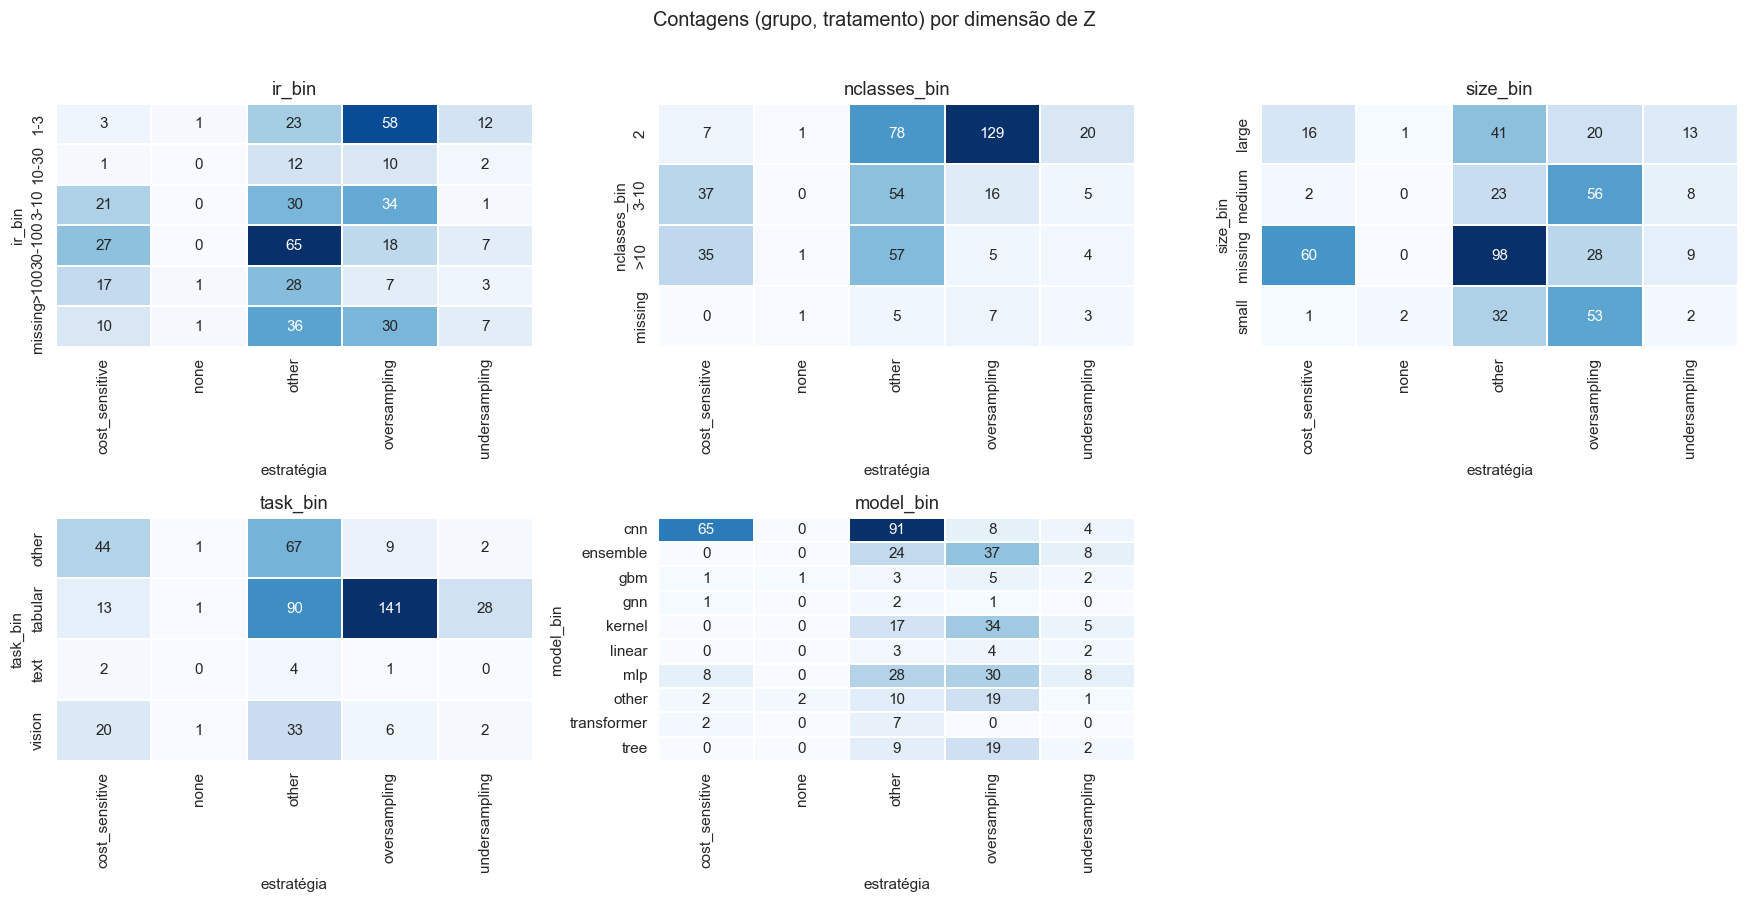

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, d in enumerate(Z_DIMS):
    ct = pd.crosstab(analysis[d], analysis["strategy"])
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues",
                ax=axes[i], cbar=False, linewidths=0.3)
    axes[i].set_title(d)
    axes[i].set_xlabel("estratégia")
    axes[i].set_ylabel(d)

axes[-1].axis("off")
plt.suptitle("Contagens (grupo, tratamento) por dimensão de Z",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Decisões de trim

Regra provisória: marca como `sparse` qualquer par cuja célula (estratégia × bin) tem $n < 3$ em **alguma** dimensão de $Z$. Esses pares são removidos antes da estimação em T5.

In [31]:
MIN_CELL_N = 3

flags = []
for d in Z_DIMS:
    counts = (
        analysis.groupby(["strategy", d]).size()
        .rename("n").reset_index()
    )
    sparse_cells = set(
        zip(counts.loc[counts["n"] < MIN_CELL_N, "strategy"],
            counts.loc[counts["n"] < MIN_CELL_N, d])
    )
    flag = analysis.apply(
        lambda r: (r["strategy"], r[d]) in sparse_cells, axis=1
    )
    flags.append(flag.rename(f"sparse_{d}"))

sparse_df = pd.concat(flags, axis=1)
analysis["is_sparse_any"] = sparse_df.any(axis=1)

print(f"Pares marcados como sparse em ≥1 dimensão: "
      f"{analysis['is_sparse_any'].sum()} "
      f"({analysis['is_sparse_any'].mean():.1%})")
print()
print("Distribuição por dimensão (quantos pares cada uma marca):")
print(sparse_df.sum().to_string())
print()
print("Estratégias depois do trim:")
print(analysis[~analysis["is_sparse_any"]]["strategy"]
      .value_counts().to_string())

Pares marcados como sparse em ≥1 dimensão: 28 (6.0%)

Distribuição por dimensão (quantos pares cada uma marca):
sparse_ir_bin           7
sparse_nclasses_bin     3
sparse_size_bin         8
sparse_task_bin        10
sparse_model_bin       19

Estratégias depois do trim:
strategy
other             192
oversampling      155
cost_sensitive     70
undersampling      20


## 9. Salvar

In [ ]:
PAPERS_PATH = PROCESSED_DIR / "papers_with_pdf.parquet"
papers_meta = (
    pd.read_parquet(PAPERS_PATH)[["paper_id", "doi", "oa_pdf_url"]]
    .drop_duplicates("paper_id")
)
print(f"Papers metadata: {len(papers_meta):,} entries")
print(f"  com DOI:     {papers_meta['doi'].notna().sum():,}")
print(f"  com URL PDF: {papers_meta['oa_pdf_url'].notna().sum():,}")

analysis_with_meta = analysis.merge(papers_meta, on="paper_id", how="left")

OUT_COLS = [
    "within_paper_group_id",
    "paper_id",
    "doi",
    "oa_pdf_url",
    "dataset_canonical",
    "strategy",
    "metric_used",
    "y_baseline", "y_treatment", "delta",
    "ir_bin", "nclasses_bin", "size_bin", "task_bin", "model_bin",
    "is_sparse_any",
]

final_df = analysis_with_meta[OUT_COLS]
final_df.to_parquet(OUT_PATH, index=False)

print(f"\nSalvo: {OUT_PATH}")
print(f"Linhas: {len(final_df):,}  |  colunas: {len(OUT_COLS)}")
print(f"Linhas usáveis (sem trim): {(~final_df['is_sparse_any']).sum():,}")
print()
print("Schema:")
print(final_df.dtypes.to_string())

Papers metadata: 1,405 entries
  com DOI:     1,167
  com URL PDF: 1,401

Salvo: C:\Users\fredb\Desktop\Faculdade\CC\2026.1\causal\causal_project\data\processed\analysis_dataset.parquet
Linhas: 465  |  colunas: 16
Linhas usáveis (sem trim): 437

Schema:
within_paper_group_id      int64
paper_id                  object
doi                       object
oa_pdf_url                object
dataset_canonical         object
strategy                  object
metric_used               object
y_baseline               float64
y_treatment              float64
delta                    float64
ir_bin                    object
nclasses_bin              object
size_bin                  object
task_bin                  object
model_bin                 object
is_sparse_any               bool


In [35]:
final_df.head(5)

,within_paper_group_id,paper_id,doi,oa_pdf_url,dataset_canonical,strategy,metric_used,y_baseline,y_treatment,delta,ir_bin,nclasses_bin,size_bin,task_bin,model_bin,is_sparse_any
0,19,arxiv:1710.05381,10.1016/j.neunet.2018.07.011,https://arxiv.org/pdf/1710.05381v2,ImageNet (ILSVRC-2012),oversampling,metric_aucroc,0.93394,0.91870,-0.016318,missing,>10,missing,vision,cnn,False
1,19,arxiv:1710.05381,10.1016/j.neunet.2018.07.011,https://arxiv.org/pdf/1710.05381v2,ImageNet (ILSVRC-2012),undersampling,metric_aucroc,0.93394,0.89600,-0.040624,missing,>10,missing,vision,cnn,True
2,62,arxiv:1807.02608,None,https://arxiv.org/pdf/1807.02608v1,LIDC,oversampling,metric_accuracy,0.66360,0.63312,-0.045931,missing,3-10,medium,tabular,ensemble,False
3,63,arxiv:1809.02596,None,https://arxiv.org/pdf/1809.02596v1,Credit-card fraud detection,oversampling,metric_f1_binary,0.88800,0.89100,0.003378,missing,2,missing,tabular,ensemble,False
4,64,arxiv:1809.02596,None,https://arxiv.org/pdf/1809.02596v1,Credit-card fraud detection,other,metric_f1_binary,0.12400,0.86300,5.959677,missing,2,missing,tabular,mlp,False


## 10. Caracterização da base final

Base final usada na estimação:
  Pares (grupo, tratamento):  437
  Within-paper groups:        273
  Papers únicos:              123
  Datasets únicos:            164

Distribuição de Δ na base final:
count    437.000
mean       0.544
std        4.247
min       -0.897
25%        0.003
50%        0.042
75%        0.137
max       72.929

Métricas usadas como outcome (qual saiu vencedora em cada grupo):
metric_used
metric_accuracy        171
metric_f1_binary       114
metric_aucroc           52
metric_f1_macro         34
metric_gmean            32
metric_balanced_acc     21
metric_mcc               7
metric_f1_micro          3
metric_auprc             3


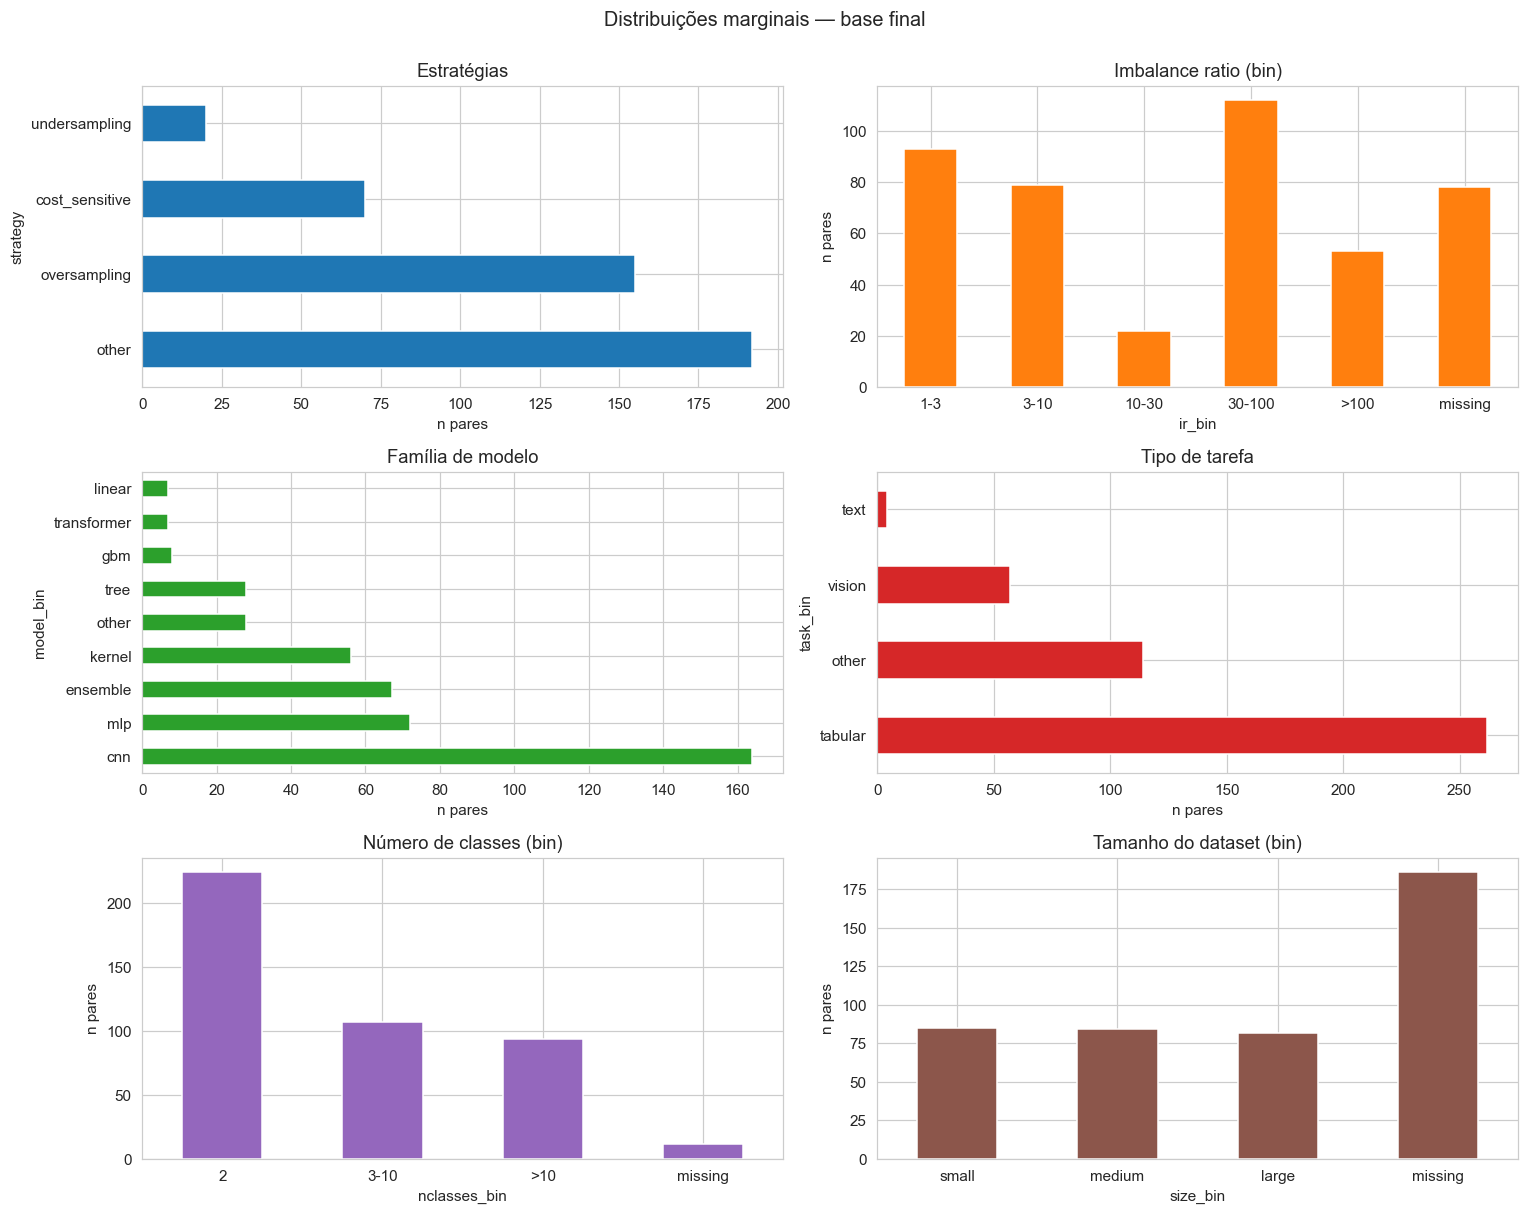

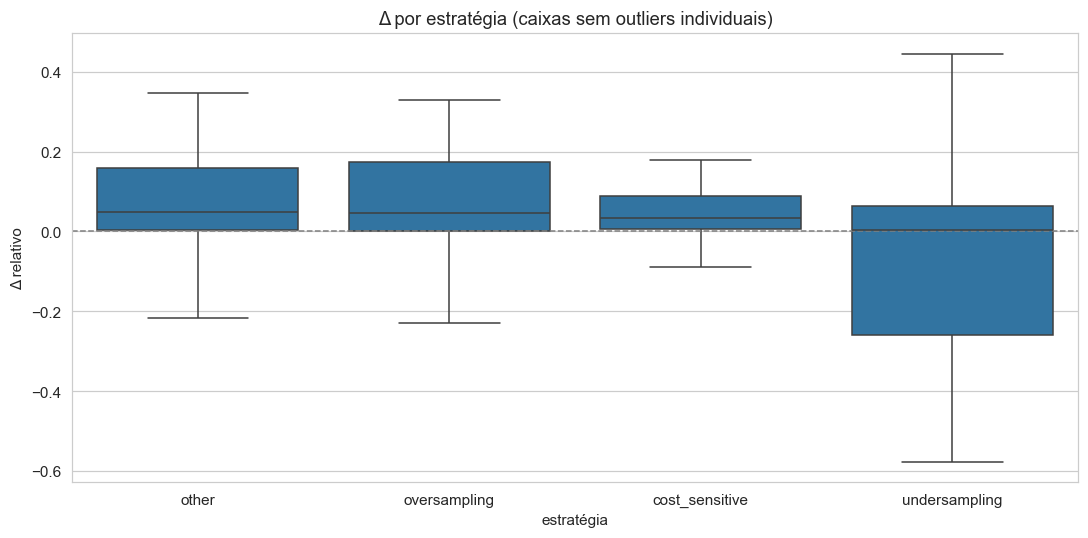

Cross-tabs: estratégia × dimensões de Z (n pares)

Estratégia × IR_bin:
ir_bin          1-3  3-10  10-30  30-100  >100  missing
strategy                                               
cost_sensitive    3    19      0      25    16        7
other            23    28     12      65    28       36
oversampling     58    32     10      18     7       30
undersampling     9     0      0       4     2        5

Estratégia × model_bin:
model_bin       cnn  ensemble  gbm  kernel  linear  mlp  other  transformer  tree
strategy                                                                         
cost_sensitive   63         0    0       0       0    7      0            0     0
other            91        24    3      17       3   28     10            7     9
oversampling      8        37    5      34       4   30     18            0    19
undersampling     2         6    0       5       0    7      0            0     0

Estratégia × task_bin:
task_bin        other  tabular  text  vision
strate

In [34]:
final = analysis[~analysis["is_sparse_any"]].copy()

# === Números gerais ===
print("Base final usada na estimação:")
print(f"  Pares (grupo, tratamento):  {len(final):,}")
print(f"  Within-paper groups:        {final['within_paper_group_id'].nunique():,}")
print(f"  Papers únicos:              {final['paper_id'].nunique():,}")
print(f"  Datasets únicos:            {final['dataset_canonical'].nunique():,}")
print()
print("Distribuição de Δ na base final:")
print(final["delta"].describe().round(3).to_string())
print()
print("Métricas usadas como outcome (qual saiu vencedora em cada grupo):")
print(final["metric_used"].value_counts().to_string())

# === Grid de distribuições marginais por bin ===
ir_order       = ["1-3", "3-10", "10-30", "30-100", ">100", "missing"]
nclasses_order = ["2", "3-10", ">10", "missing"]
size_order     = ["small", "medium", "large", "missing"]

fig, axes = plt.subplots(3, 2, figsize=(14, 11))

final["strategy"].value_counts().plot(kind="barh", ax=axes[0, 0], color="C0")
axes[0, 0].set_title("Estratégias")
axes[0, 0].set_xlabel("n pares")

(final["ir_bin"].value_counts()
 .reindex(ir_order).fillna(0)
 .plot(kind="bar", ax=axes[0, 1], color="C1"))
axes[0, 1].set_title("Imbalance ratio (bin)")
axes[0, 1].set_ylabel("n pares")
axes[0, 1].tick_params(axis="x", rotation=0)

final["model_bin"].value_counts().plot(kind="barh", ax=axes[1, 0], color="C2")
axes[1, 0].set_title("Família de modelo")
axes[1, 0].set_xlabel("n pares")

final["task_bin"].value_counts().plot(kind="barh", ax=axes[1, 1], color="C3")
axes[1, 1].set_title("Tipo de tarefa")
axes[1, 1].set_xlabel("n pares")

(final["nclasses_bin"].value_counts()
 .reindex(nclasses_order).fillna(0)
 .plot(kind="bar", ax=axes[2, 0], color="C4"))
axes[2, 0].set_title("Número de classes (bin)")
axes[2, 0].set_ylabel("n pares")
axes[2, 0].tick_params(axis="x", rotation=0)

(final["size_bin"].value_counts()
 .reindex(size_order).fillna(0)
 .plot(kind="bar", ax=axes[2, 1], color="C5"))
axes[2, 1].set_title("Tamanho do dataset (bin)")
axes[2, 1].set_ylabel("n pares")
axes[2, 1].tick_params(axis="x", rotation=0)

plt.suptitle("Distribuições marginais — base final", y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

# === Δ por estratégia ===
fig, ax = plt.subplots(figsize=(10, 5))
order = (final.groupby("strategy")["delta"].median()
         .sort_values(ascending=False).index)
sns.boxplot(data=final, x="strategy", y="delta", order=order, ax=ax,
            showfliers=False, color="C0")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Δ por estratégia (caixas sem outliers individuais)")
ax.set_ylabel("Δ relativo")
ax.set_xlabel("estratégia")
plt.tight_layout()
plt.show()

# === Cross-tabs ===
print("=" * 60)
print("Cross-tabs: estratégia × dimensões de Z (n pares)")
print("=" * 60)

print("\nEstratégia × IR_bin:")
ct = pd.crosstab(final["strategy"], final["ir_bin"])
ct = ct.reindex(columns=[c for c in ir_order if c in ct.columns], fill_value=0)
print(ct.to_string())

print("\nEstratégia × model_bin:")
print(pd.crosstab(final["strategy"], final["model_bin"]).to_string())

print("\nEstratégia × task_bin:")
print(pd.crosstab(final["strategy"], final["task_bin"]).to_string())

# === Top datasets ===
print("\n" + "=" * 60)
print("Top 15 datasets na base final (por nº de pares):")
print("=" * 60)
print(final["dataset_canonical"].value_counts().head(15).to_string())

In [36]:
df_final = pd.read_parquet(OUT_PATH)
df_final.head(5)

,within_paper_group_id,paper_id,doi,oa_pdf_url,dataset_canonical,strategy,metric_used,y_baseline,y_treatment,delta,ir_bin,nclasses_bin,size_bin,task_bin,model_bin,is_sparse_any
0,19,arxiv:1710.05381,10.1016/j.neunet.2018.07.011,https://arxiv.org/pdf/1710.05381v2,ImageNet (ILSVRC-2012),oversampling,metric_aucroc,0.93394,0.91870,-0.016318,missing,>10,missing,vision,cnn,False
1,19,arxiv:1710.05381,10.1016/j.neunet.2018.07.011,https://arxiv.org/pdf/1710.05381v2,ImageNet (ILSVRC-2012),undersampling,metric_aucroc,0.93394,0.89600,-0.040624,missing,>10,missing,vision,cnn,True
2,62,arxiv:1807.02608,None,https://arxiv.org/pdf/1807.02608v1,LIDC,oversampling,metric_accuracy,0.66360,0.63312,-0.045931,missing,3-10,medium,tabular,ensemble,False
3,63,arxiv:1809.02596,None,https://arxiv.org/pdf/1809.02596v1,Credit-card fraud detection,oversampling,metric_f1_binary,0.88800,0.89100,0.003378,missing,2,missing,tabular,ensemble,False
4,64,arxiv:1809.02596,None,https://arxiv.org/pdf/1809.02596v1,Credit-card fraud detection,other,metric_f1_binary,0.12400,0.86300,5.959677,missing,2,missing,tabular,mlp,False
